## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from collections import OrderedDict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import resnet50, ResNet50_Weights, vit_b_32, ViT_B_32_Weights, convnext_base, ConvNeXt_Base_Weights
import matplotlib.pyplot as plt

from deepfake_utils.datasets import DeepFakeDataset
from deepfake_utils.models import MyModel
from deepfake_utils.train import validate_epoch

import cv2, os
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
experiment_results = pd.read_csv("experiment_results.csv")

In [4]:
# focus on evaluating the best model settings for each family (i.e. 1 for ResNet, 1 for ViT, 1 for ConvNeXt)
# "best" is open to redefining a bit later depending on model complexity etc. but maybe just go with highest ROC AUC on validation data for now
experiment_results.sort_values(by='val_roc_auc', ascending = False).groupby("model").first()[['experiment_id', 'freeze_layers', 'val_roc_auc', 'val_pr_auc', 'val_acc', 'val_loss', 'train_roc_auc', 'train_pr_auc', 'train_acc', 'train_loss']]
# experiment_results.sort_values(by='val_roc_auc', ascending = False).groupby("model").head(3)

,experiment_id,freeze_layers,val_roc_auc,val_pr_auc,val_acc,val_loss,train_roc_auc,train_pr_auc,train_acc,train_loss
model,,,,,,,,,,
ConvNeXt-base-pretrained,1,False,0.821407,0.875405,0.753425,0.904670,0.995513,0.997641,0.979487,0.066293
ResNet-50-pretrained,33,False,0.872955,0.921372,0.770548,0.842997,0.999989,0.999993,0.998535,0.010255
ViT-b32-pretrained,26,True,0.785433,0.847986,0.719178,0.540543,0.865407,0.907342,0.793407,0.453412


In [5]:
# load models with weights from training
resnet_model_weights = OrderedDict([(k.replace("_orig_mod.", ""), v) for k, v in torch.load('experiment_33.pth', weights_only=True, map_location = device).items()])
resnet_model = MyModel("ResNet-50-pretrained", device, num_classes=2, freeze_layers=False)
resnet_model.load_state_dict(resnet_model_weights)

vit_model_weights = OrderedDict([(k.replace("_orig_mod.", ""), v) for k, v in torch.load('experiment_26.pth', weights_only=True, map_location = device).items()])
vit_model = MyModel("ViT-b32-pretrained", device, num_classes=2, freeze_layers=False)
vit_model.load_state_dict(vit_model_weights)

convnext_model_weights = OrderedDict([(k.replace("_orig_mod.", ""), v) for k, v in torch.load('experiment_1.pth', weights_only=True, map_location = device).items()])
convnext_model = MyModel("ConvNeXt-base-pretrained", device, num_classes=2, freeze_layers=False)
convnext_model.load_state_dict(convnext_model_weights)

<All keys matched successfully>

In [6]:
image_dir_path = 'Deepfake-Eval-2024/image-data'
debug_data = DeepFakeDataset("image-metadata-debug.csv", image_dir_path, model_type = 'ResNet', is_train = False, return_filename=True)
debug_data_loader = DataLoader(debug_data, batch_size = 32, shuffle = False)

test_data = DeepFakeDataset("image-metadata-test.csv", image_dir_path, model_type = 'ResNet',  is_train = False, return_filename=True)
test_data_loader = DataLoader(test_data, batch_size = 32, shuffle = False)

In [7]:
batch_X, batch_y, batch_filenames = next(iter(test_data_loader))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1345534].


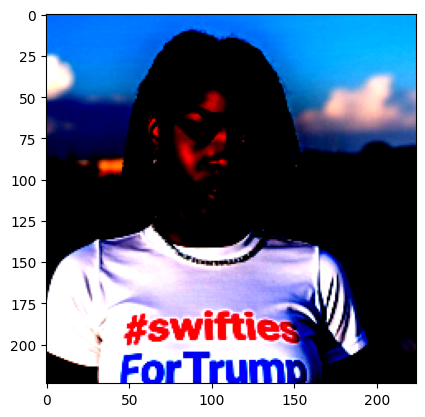

In [11]:
plt.imshow(np.transpose(batch_X[1], (1,2,0)))
plt.show()

In [12]:
# rgb_img = cv2.imread(os.path.join('Deepfake-Eval-2024/image-data/',batch_filenames[0]), 1)[:, :, ::-1]
# rgb_img = np.float32(rgb_img) / 255
rgb_img = np.float32(np.transpose(batch_X[1].numpy(), (1,2,0))) / 255

from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [resnet_model.model.layer4[-1]]
input_tensor = batch_X # Create an input tensor image for your model..
# Note: input_tensor can be a batch tensor with several images!

# We have to specify the target we want to generate the CAM for.
targets = [ClassifierOutputTarget(1)]

# Construct the CAM object once, and then re-use it on many images.
with GradCAM(model=resnet_model, target_layers=target_layers) as cam:
  # You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
  # In this example grayscale_cam has only one image in the batch:
  grayscale_cam = grayscale_cam[0, :]
  visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
  # You can also get the model outputs without having to redo inference
  model_outputs = cam.outputs

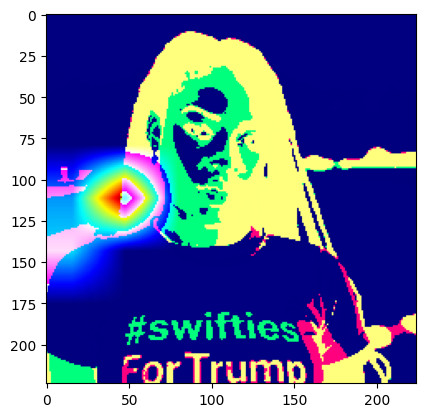

In [13]:
plt.imshow(visualization)